## Similarity vs. Globality Anaysis
Here we analyze the dependance of the similarity metric on globality 

In [145]:
import os
# change to platonic-rep root directory
os.chdir(r'c:\Users\user\OneDrive - Technion\Documents\GitHub\platonic-rep')
# os.chdir(r'c:\Users\barweiss\OneDrive - Technion\Documents\GitHub\platonic-rep')

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
import utils 
from tasks import get_models

import pandas as pd
import seaborn as sns

# sim_params = {
#     'modelset': 'val',
#     'dataset': 'minhuh\\prh',
#     'subset': 'wit_1024',
#     'modality_x': 'vision',
#     'modality_y': 'vision',
#     'pool_x': 'cls',
#     'pool_y': 'cls',
#     'prompt_x': False,
#     'prompt_y': False,
#     'metric': 'dka_rbf',
#     'sweep_len': 40,
#     'layer_mode': 'final',
#     'run_name': 'test'
# }

# sim_params = {
#     'modelset': 'val',
#     'dataset': 'minhuh\\prh',
#     'subset': 'wit_1024',
#     'modality_x': 'language',
#     'modality_y': 'language',
#     'pool_x': 'avg',
#     'pool_y': 'avg',
#     'prompt_x': False,
#     'prompt_y': False,
#     'metric': 'softmax_cka',
#     'sweep_len': 40,
#     'layer_mode': 'final',
#     'run_name': 'test'
# }

sim_params = {
    'modelset': 'val',
    'dataset': 'minhuh\\prh',
    'subset': 'wit_1024',
    'modality_x': 'language',
    'modality_y': 'vision',
    'pool_x': 'avg',
    'pool_y': 'cls',
    'prompt_x': False,
    'prompt_y': False,
    'metric': 'dka_rbf',
    'sweep_len': 40,
    'layer_mode': 'final',
    'run_name': 'test',
}

# plotting params
fontsize = 16

# get alignment data path
results_dir = os.path.join('results', 'alignment')
load_path = utils.to_alignment_filename(
            results_dir, sim_params['dataset'], sim_params['modelset'],
            sim_params['modality_x'], sim_params['pool_x'], sim_params['prompt_x'],
            sim_params['modality_y'], sim_params['pool_y'], sim_params['prompt_y'],
            sim_params['metric'], sim_params['sweep_len'], layer_mode=sim_params['layer_mode'],
            run_name=sim_params.get('run_name', 'test')
    )

# define figure path
figure_path = os.path.join('post_processing', 'figures', f'{sim_params["modelset"]}_{sim_params["subset"]}', 
                           f'{sim_params.get("run_name", "test")}',
                           f'{sim_params["metric"]}_layer_{sim_params["layer_mode"]}', 
                           f'{sim_params["modality_x"]}_vs_{sim_params["modality_y"]}')
os.makedirs(figure_path, exist_ok=True)

# load alignment data
data = np.load(load_path, allow_pickle=True).item()

In [147]:
n_models = data['scores'].shape[0]
llm_models, lvm_models = get_models(sim_params['modelset'], modality='all')
model_names_x = llm_models if sim_params['modality_x'] == "language" else lvm_models
model_names_y = llm_models if sim_params['modality_y'] == "language" else lvm_models

In [148]:
print(model_names_x)
print(model_names_y)

['bigscience/bloomz-560m', 'bigscience/bloomz-1b1', 'bigscience/bloomz-1b7', 'bigscience/bloomz-3b', 'bigscience/bloomz-7b1', 'openlm-research/open_llama_3b', 'openlm-research/open_llama_7b', 'openlm-research/open_llama_13b', 'huggyllama/llama-7b', 'huggyllama/llama-13b', 'huggyllama/llama-30b', 'huggyllama/llama-65b']
['vit_tiny_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_large_patch16_224.mae', 'vit_huge_patch14_224.mae', 'vit_small_patch14_dinov2.lvd142m', 'vit_base_patch14_dinov2.lvd142m', 'vit_large_patch14_dinov2.lvd142m', 'vit_giant_patch14_dinov2.lvd142m', 'vit_base_patch16_clip_224.laion2b', 'vit_large_patch14_clip_224.laion2b', 'vit_huge_patch14_clip_224.laion2b', 'vit_base_patch16_clip_224.laion2b_ft_in12k', 'vit_large_patch14_clip_224.laion2b_ft_in12k', 'vit_huge_patch14_clip_224.laion2b_ft_in12k']


In [149]:
model_names_map = {
    # vision models
    'vit_tiny_patch16_224.augreg_in21k': 'AugReg-tiny',
    'vit_small_patch16_224.augreg_in21k': 'AugReg-small',
    'vit_base_patch16_224.augreg_in21k': 'AugReg-base',
    'vit_large_patch16_224.augreg_in21k': 'AugReg-large',
    'vit_base_patch16_224.mae': 'MAE-base',
    'vit_large_patch16_224.mae': 'MAE-large',
    'vit_huge_patch14_224.mae': 'MAE-huge',
    'vit_small_patch14_dinov2.lvd142m': 'DINOv2-small',
    'vit_base_patch14_dinov2.lvd142m': 'DINOv2-base',
    'vit_large_patch14_dinov2.lvd142m': 'DINOv2-large',
    'vit_giant_patch14_dinov2.lvd142m': 'DINOv2-giant',
    'vit_base_patch16_clip_224.laion2b': 'CLIP-base',
    'vit_large_patch14_clip_224.laion2b': 'CLIP-large',
    'vit_huge_patch14_clip_224.laion2b': 'CLIP-huge',
    'vit_base_patch16_clip_224.laion2b_ft_in12k': 'CLIP-base-ft',
    'vit_large_patch14_clip_224.laion2b_ft_in12k': 'CLIP-large-ft',
    'vit_huge_patch14_clip_224.laion2b_ft_in12k': 'CLIP-huge-ft',
    # language models
    'bigscience/bloomz-560m': 'BLOOMZ-560M',
    'bigscience/bloomz-1b1': 'BLOOMZ-1B1',
    'bigscience/bloomz-1b7': 'BLOOMZ-1B7',
    'bigscience/bloomz-3b': 'BLOOMZ-3B',
    'bigscience/bloomz-7b1': 'BLOOMZ-7B1',
    'openlm-research/open_llama_3b': 'OpenLLaMA-3B',
    'openlm-research/open_llama_7b': 'OpenLLaMA-7B',
    'openlm-research/open_llama_13b': 'OpenLLaMA-13B',
    'huggyllama/llama-7b': 'HuggyLLaMA-7B',
    'huggyllama/llama-13b': 'HuggyLLaMA-13B',
    'huggyllama/llama-30b': 'HuggyLLaMA-30B',
    'huggyllama/llama-65b': 'HuggyLLaMA-65B',

}

In [150]:
# plot alignment vs. topk values for models in model list
vision_model_families: list[str] = ['augreg', 'mae', 'dinov2', 'clip']
vision_size_families: dict[str, list[str]] = {
    "tiny": ['vit_tiny_patch16_224.augreg_in21k'],
    "small": ['vit_small_patch16_224.augreg_in21k', 'vit_small_patch14_dinov2.lvd142m'],
    "base": ['vit_base_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_base_patch14_dinov2.lvd142m', 
             'vit_base_patch16_clip_224.laion2b', 'vit_base_patch16_clip_224.laion2b_ft_in12k'],
    "large": ['vit_large_patch16_224.augreg_in21k', 'vit_large_patch14_dinov2.lvd142m', 'vit_large_patch16_224.mae', 
              'vit_large_patch14_clip_224.laion2b', 'vit_large_patch14_clip_224.laion2b_ft_in12k'],
    "huge": ['vit_huge_patch14_224.mae', 'vit_huge_patch14_clip_224.laion2b','vit_huge_patch14_clip_224.laion2b_ft_in12k'],
    "giant": ['vit_giant_patch14_dinov2.lvd142m'],
}
language_model_families = ['bloomz', 'open_llama', 'huggyllama']
# group models by size
langauge_size_families = {
    "tiny": ['bigscience/bloomz-560m'],
    "small": ['bigscience/bloomz-1b1', 'bigscience/bloomz-1b7', 'bigscience/bloomz-3b', 'openlm-research/open_llama_3b'],
    "base": ['bigscience/bloomz-7b1', 'openlm-research/open_llama_7b', 'huggyllama/llama-7b'],
    "large": ['openlm-research/open_llama_13b', 'huggyllama/llama-13b'],
    "huge": ['huggyllama/llama-30b'],
    "giant": ['huggyllama/llama-65b'],
}


In [151]:
def plot_similarity_globality(
        data, 
        model_names_x: list[str], 
        model_names_y: list[str],
        model_family_x: str, 
        model_family_y: str, 
        figure_path: str,
        fontsize=16,
        log_scale=False):
    """
    Plot similarity vs. globality for models in specified families.
    
    Args:
        log_scale: If True, use logarithmic scale for x-axis
    """
    
    sweep_vec = data['param_vec']
    param_name = data['param_name']
    same_family = model_family_x == model_family_y
    # filter models by family if model name conatins the family string
    model_list_x = [m for m in model_names_x if model_family_x in m]
    model_list_y = [m for m in model_names_y if model_family_y in m]
    # print(f"Plotting {model_family_x} vs. {model_family_y}:")
    # print(f"  Models X: {model_list_x}")
    # print(f"  Models Y: {model_list_y}")
    model_pairs = []
    plt.figure(figsize=(10,6))
    for i, model_x in enumerate(model_list_x):
        model_x_idx = model_names_x.index(model_x)
        for j, model_y in enumerate(model_list_y):
            model_y_idx = model_names_y.index(model_y)
            if same_family and i == j:
                continue
            if (model_y, model_x) in model_pairs:
                continue
            model_pairs.append((model_x, model_y))
            alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
            label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
            plt.plot(sweep_vec, alignment_scores, marker='o', label=label)

    plt.xlabel(f'Globality[{param_name}]', fontsize=fontsize)
    plt.ylabel(f'{sim_params["metric"]} score', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.yticks(fontsize=fontsize-2)
    
    # Set log scale if requested
    if log_scale:
        plt.xscale('log')
    
    plt.grid(True)
    plt.legend(fontsize=fontsize)
    plt.savefig(f'{figure_path}/sim_globality_{model_family_x}_vs_{model_family_y}.png', dpi=300)

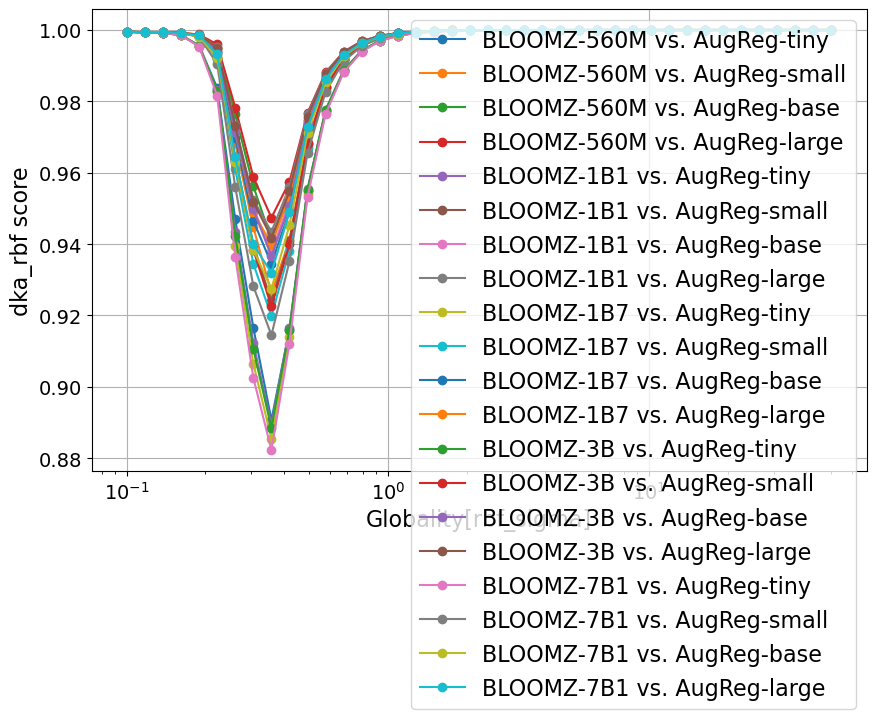

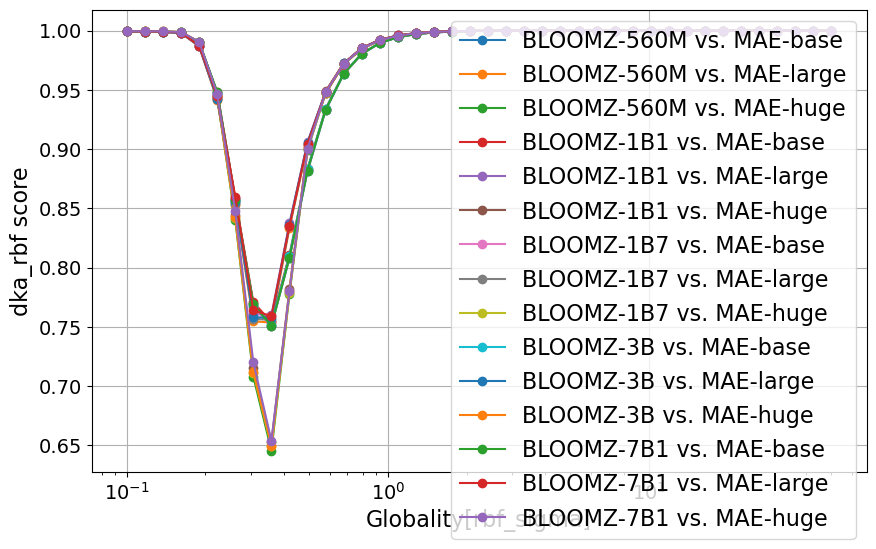

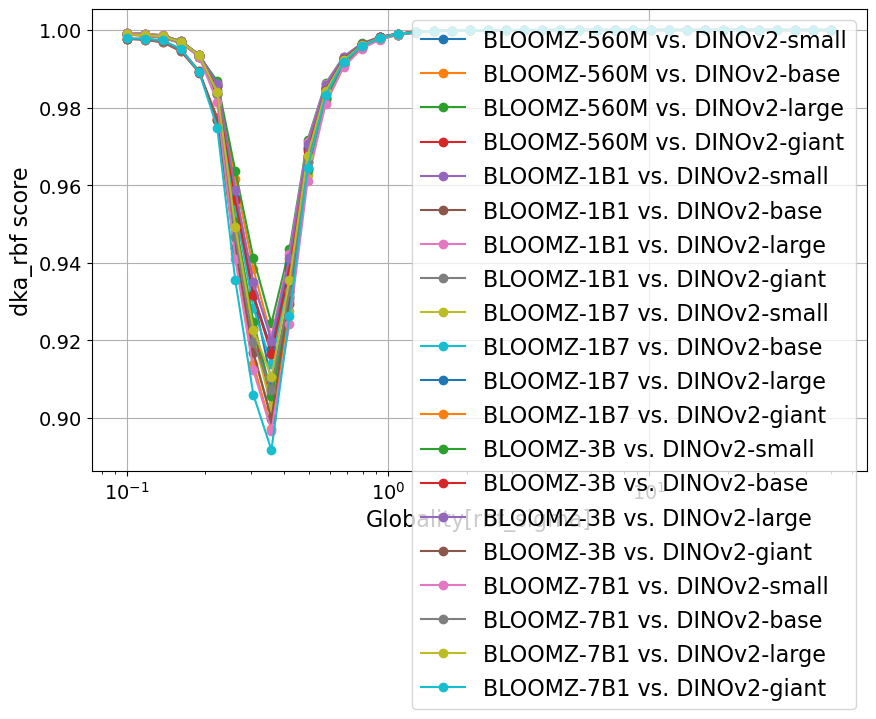

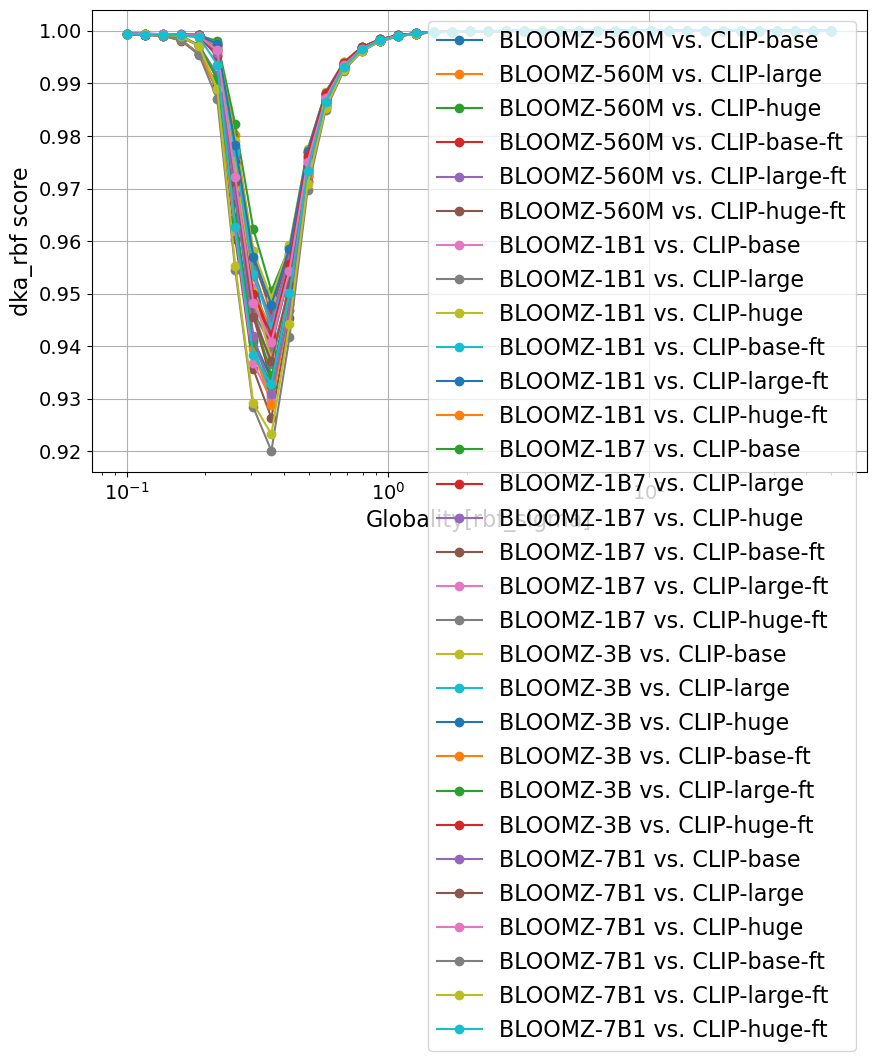

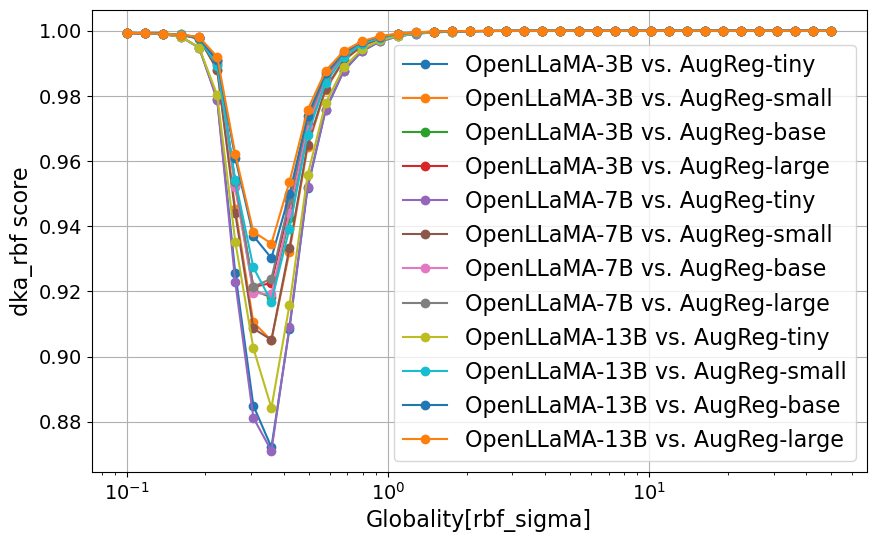

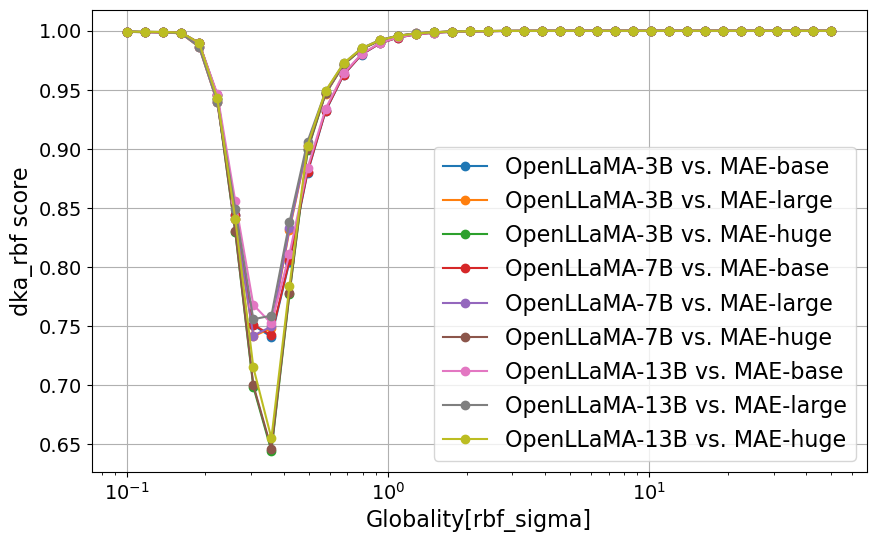

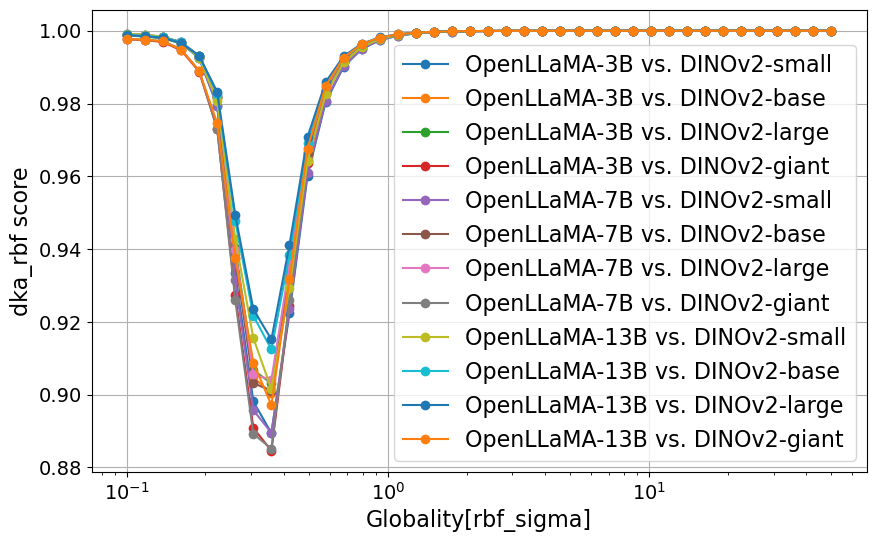

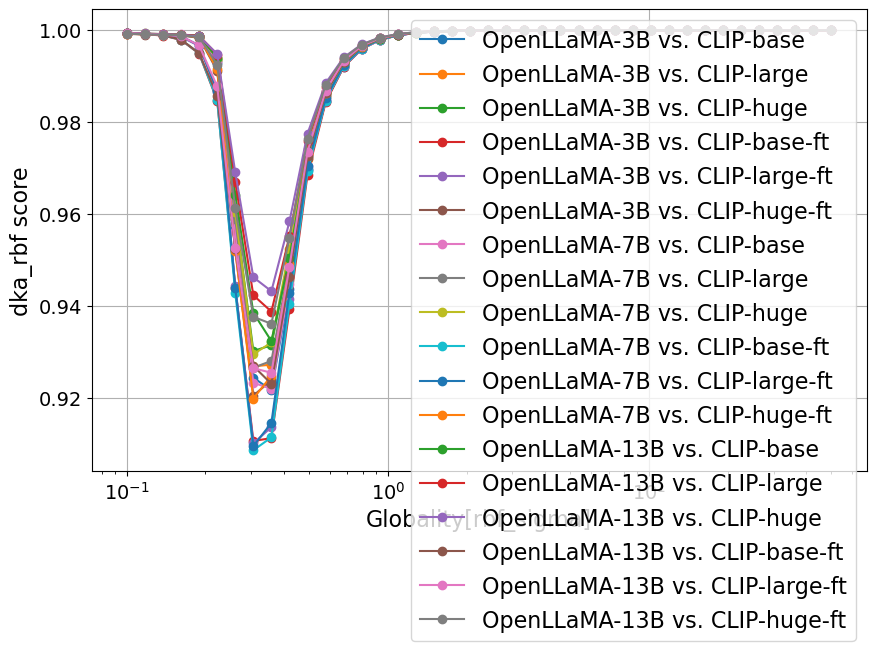

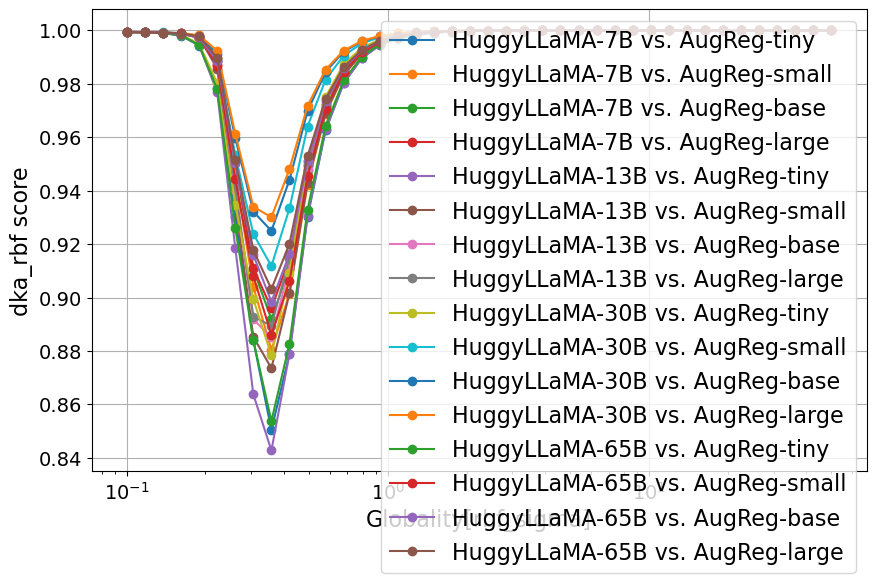

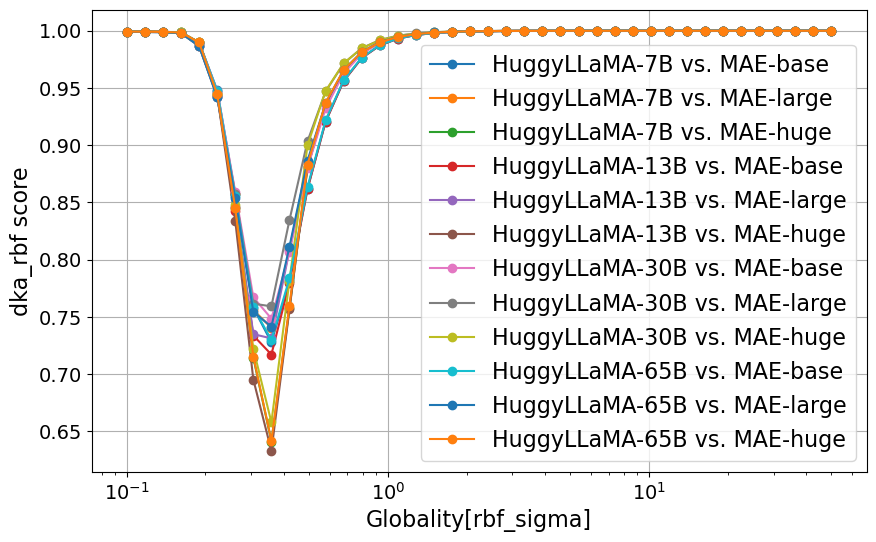

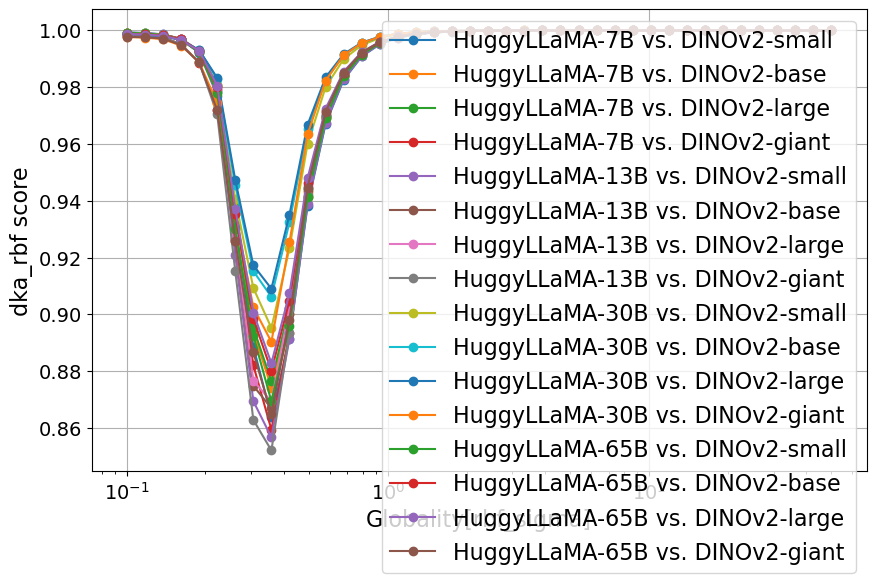

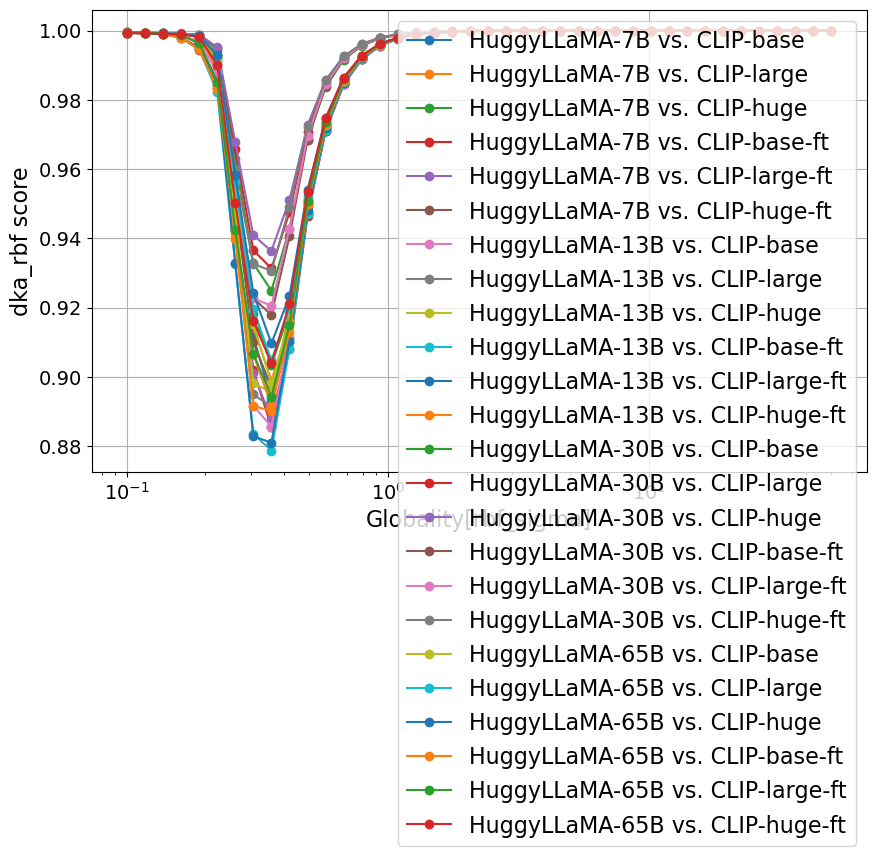

In [152]:
families_x = vision_model_families if sim_params['modality_x'] == "vision" else language_model_families
families_y = vision_model_families if sim_params['modality_y'] == "vision" else language_model_families

# use log scale if sweep_vec is not evenely spaced
sweep_vec = data['param_vec']
# log_scale = not np.allclose(np.diff(sweep_vec), np.diff(sweep_vec)[0])
log_scale = True 

# plot similarity vs. globality for each unique family pair
family_pairs = []
for fam_x in families_x:
    for fam_y in families_y:
        if (fam_y, fam_x) in family_pairs:
            continue
        family_pairs.append((fam_x, fam_y))
        plot_similarity_globality(
            data, model_names_x, model_names_y,
            fam_x, fam_y,
            figure_path,
            fontsize=fontsize,
            log_scale=log_scale  # Enable logarithmic x-axis
        )

## Aggregate Analysis: Total Variation vs. Median & Max vs. Min Similarity
Compute total variation (weighted by sweep parameter spacing) and similarity statistics for each model pair

In [153]:
def compute_aggregates(data, model_names_x, model_names_y, model_family_x, model_family_y):
    """
    Compute total variation, convexity, AUC, and similarity statistics for model pairs.
    
    Total Variation: sum of |dy/dx| * |dx| where dy is the change in similarity
                     and dx is the change in sweep parameter
    Convexity: sum of second derivatives (measures curvature)
    AUC: Area Under Curve using trapezoidal integration
    Median Similarity: median similarity across all globality values
    Max Similarity: maximum similarity across all globality values
    Min Similarity: minimum similarity across all globality values
    """
    same_family = model_family_x == model_family_y
    model_list_x = [m for m in model_names_x if model_family_x in m]
    model_list_y = [m for m in model_names_y if model_family_y in m]
    
    sweep_vec = data['param_vec']
    results = []
    model_pairs = []
    
    for i, model_x in enumerate(model_list_x):
        model_x_idx = model_names_x.index(model_x)
        for j, model_y in enumerate(model_list_y):
            model_y_idx = model_names_y.index(model_y)
            
            # Skip same model pairs and duplicates
            if same_family and i == j:
                continue
            if (model_y, model_x) in model_pairs:
                continue
            
            model_pairs.append((model_x, model_y))
            alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
            
            # Compute metrics
            # Total variation: sum of |dy/dx| * |dx|
            dy = np.diff(alignment_scores)
            # dx = np.diff(sweep_vec)
            # total_variation = np.sum(np.abs(dy / dx) * np.abs(dx))  # simplifies to np.sum(np.abs(dy))
            # But we keep it explicit to show we're considering the sweep parameter
            total_variation = np.sum(np.abs(dy))  # Since dx cancels out
            
            # Convexity: sum of second derivatives
            # Second derivative approximation: d²y/dx² ≈ (y[i+1] - 2*y[i] + y[i-1]) / dx²
            dy = np.diff(alignment_scores) 
            dx = np.diff(sweep_vec)
            d2y = np.diff(dy / dx) / dx[:-1]
            convexity = np.sum(d2y)  # Sum of second derivatives (positive = convex, negative = concave)
            
            # Area Under Curve: using trapezoidal rule
            auc = np.trapezoid(alignment_scores, sweep_vec)
            
            median_similarity = np.median(alignment_scores)
            max_similarity = np.max(alignment_scores)
            min_similarity = np.min(alignment_scores)
            mean_similarity = np.mean(alignment_scores)
            
            label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
            
            results.append({
                'model_pair': label,
                'model_x': model_names_map.get(model_x, model_x),
                'model_y': model_names_map.get(model_y, model_y),
                'family_x': model_family_x,
                'family_y': model_family_y,
                'total_variation': total_variation,
                'convexity': convexity,
                'auc': auc,
                'median_similarity': median_similarity,
                'max_similarity': max_similarity,
                'min_similarity': min_similarity,
                'mean_similarity': mean_similarity
            })
    
    return pd.DataFrame(results)

In [154]:
# Compute aggregates for all family pairs
all_aggregates = []

for fam_x, fam_y in family_pairs:
    df = compute_aggregates(data, model_names_x, model_names_y, fam_x, fam_y)
    all_aggregates.append(df)

# Combine all results
aggregates_df = pd.concat(all_aggregates, ignore_index=True)
print(f"Total model pairs analyzed: {len(aggregates_df)}")
aggregates_df.head(10)

Total model pairs analyzed: 204


,model_pair,model_x,model_y,family_x,family_y,total_variation,convexity,auc,median_similarity,max_similarity,min_similarity,mean_similarity
0,BLOOMZ-560M vs. AugReg-tiny,BLOOMZ-560M,AugReg-tiny,bloomz,augreg,0.218000,-7.864250,49.872244,0.999910,1.0,0.890732,0.988869
1,BLOOMZ-560M vs. AugReg-small,BLOOMZ-560M,AugReg-small,bloomz,augreg,0.146959,-4.823777,49.881242,0.999935,1.0,0.926252,0.992613
2,BLOOMZ-560M vs. AugReg-base,BLOOMZ-560M,AugReg-base,bloomz,augreg,0.116738,-3.695927,49.885058,0.999947,1.0,0.941353,0.994127
3,BLOOMZ-560M vs. AugReg-large,BLOOMZ-560M,AugReg-large,bloomz,augreg,0.104637,-3.279371,49.886365,0.999950,1.0,0.947418,0.994654
4,BLOOMZ-1B1 vs. AugReg-tiny,BLOOMZ-1B1,AugReg-tiny,bloomz,augreg,0.220478,-8.134634,49.871953,0.999911,1.0,0.889493,0.988669
5,BLOOMZ-1B1 vs. AugReg-small,BLOOMZ-1B1,AugReg-small,bloomz,augreg,0.151555,-5.152711,49.880706,0.999936,1.0,0.923954,0.992320
6,BLOOMZ-1B1 vs. AugReg-base,BLOOMZ-1B1,AugReg-base,bloomz,augreg,0.123611,-4.119792,49.884239,0.999948,1.0,0.937918,0.993716
7,BLOOMZ-1B1 vs. AugReg-large,BLOOMZ-1B1,AugReg-large,bloomz,augreg,0.112501,-3.729358,49.885448,0.999950,1.0,0.943486,0.994203
8,BLOOMZ-1B7 vs. AugReg-tiny,BLOOMZ-1B7,AugReg-tiny,bloomz,augreg,0.228530,-8.608357,49.870795,0.999908,1.0,0.885470,0.988178
9,BLOOMZ-1B7 vs. AugReg-small,BLOOMZ-1B7,AugReg-small,bloomz,augreg,0.159866,-5.582136,49.879583,0.999933,1.0,0.919802,0.991853


Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\aggregate_tv_vs_median_similarity.png


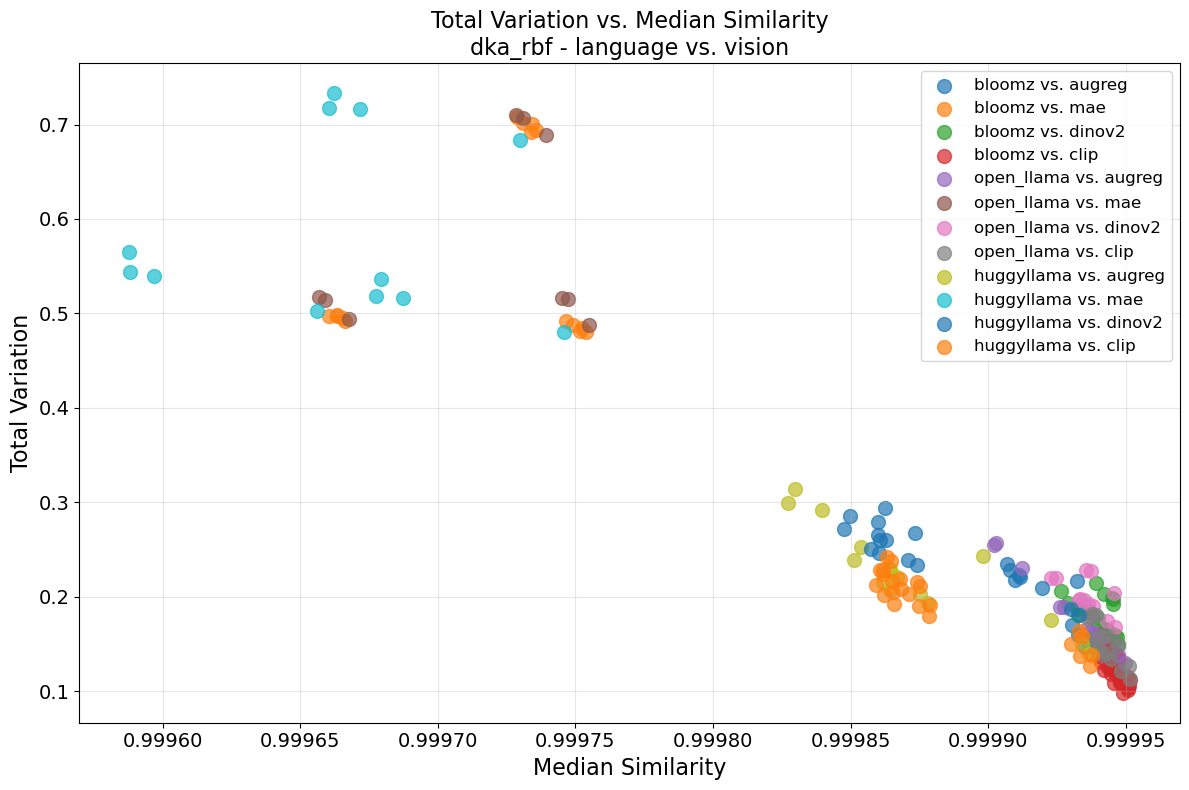

Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\aggregate_range_vs_mean_similarity.png


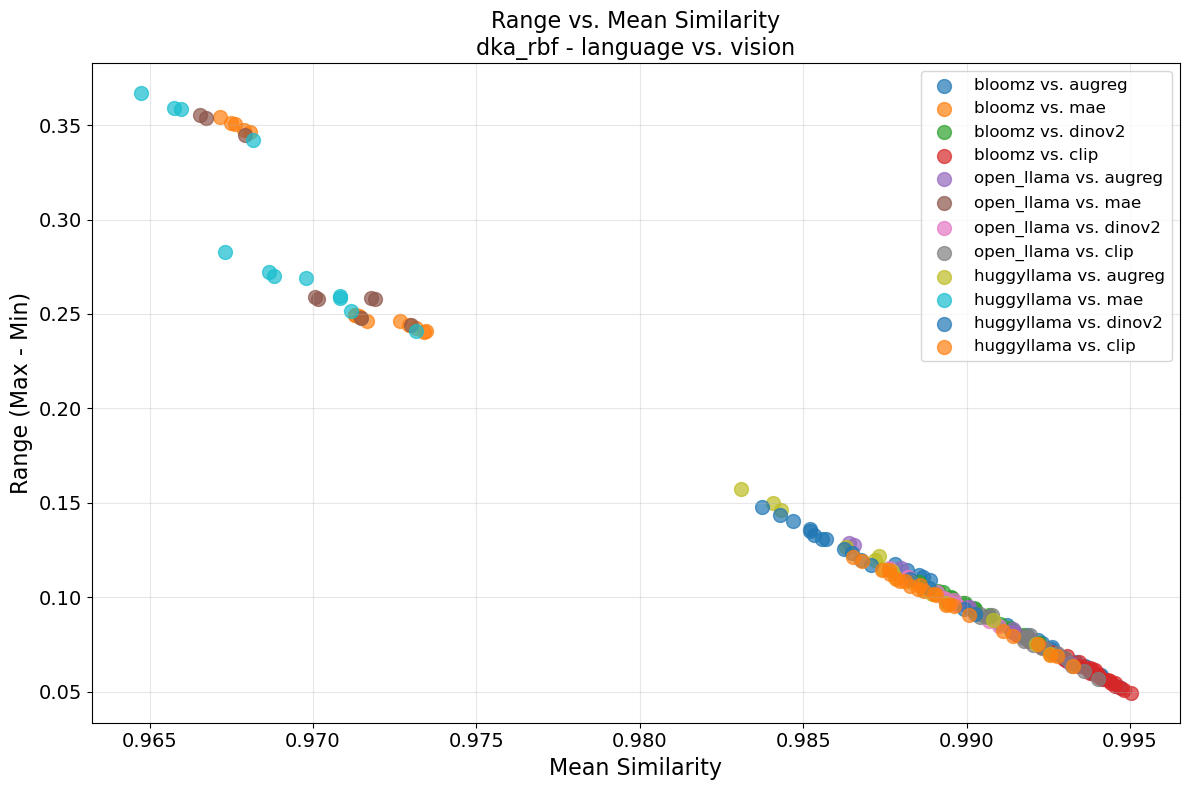

Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\aggregate_convexity_vs_median_similarity.png


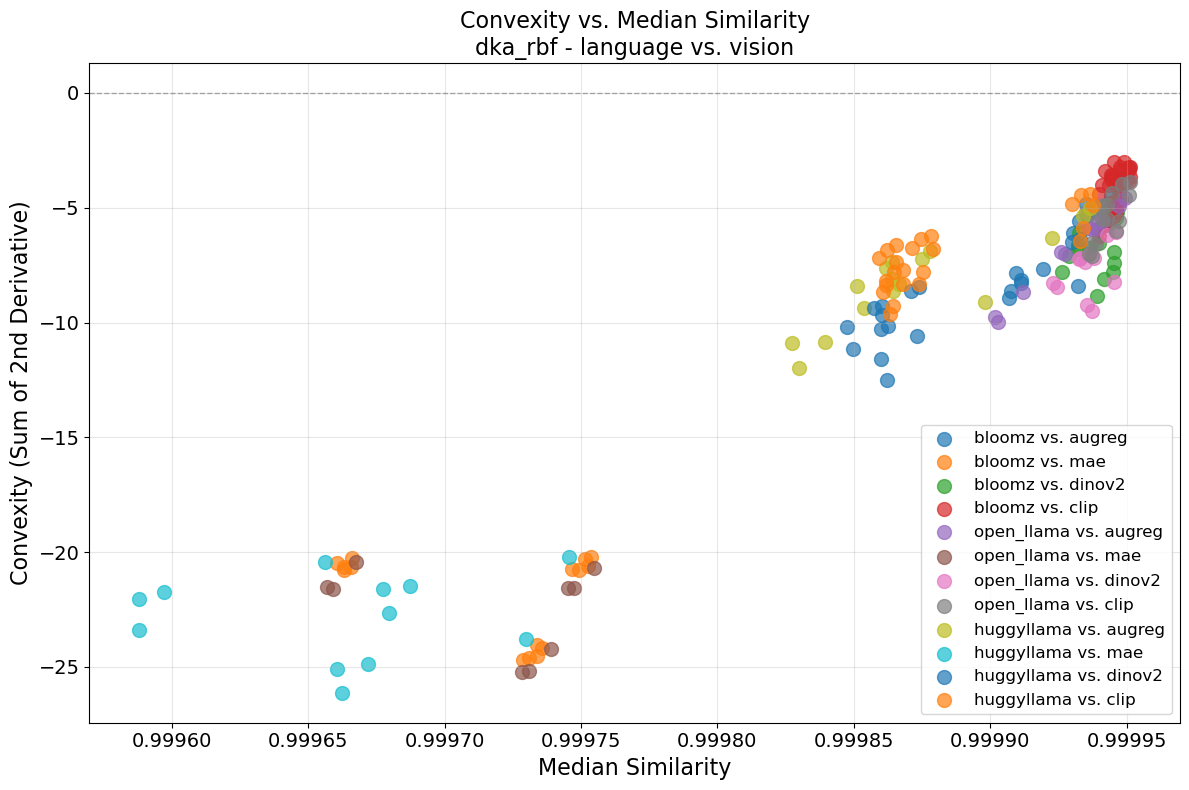

Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\aggregate_tv_vs_auc.png


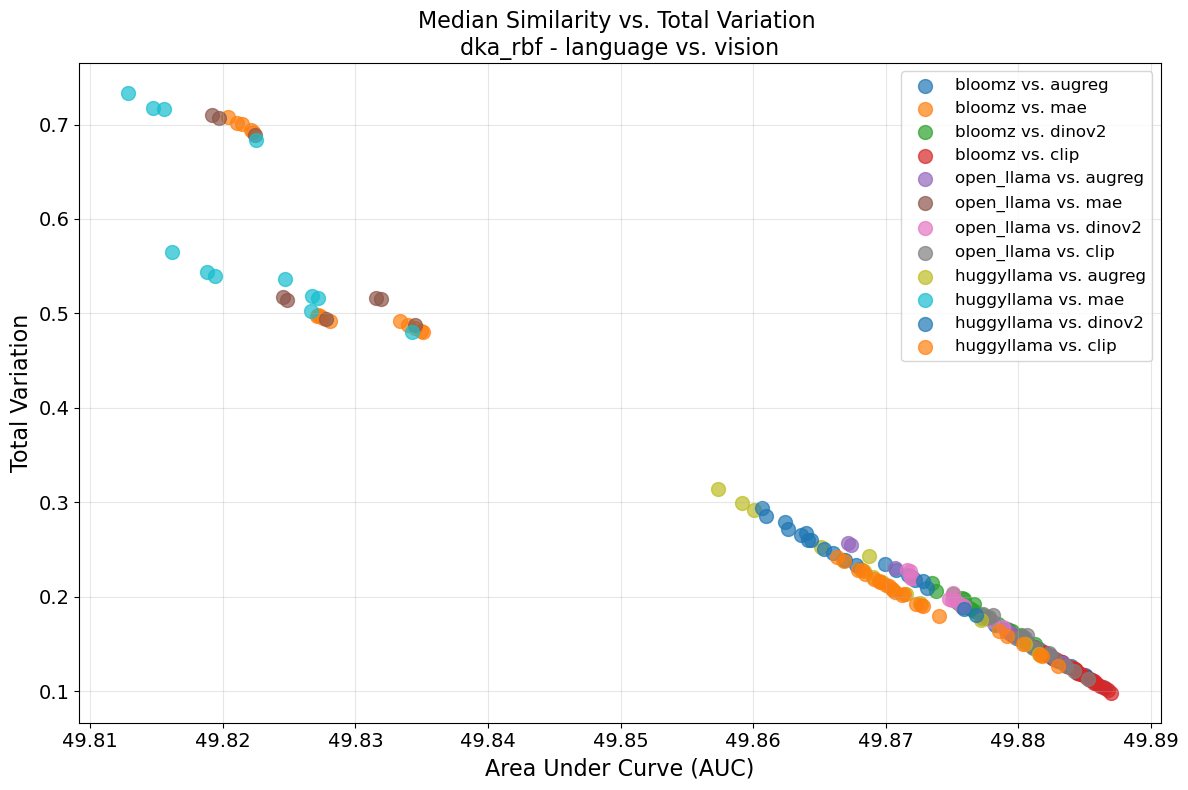

In [155]:
# Create scatter plots

# Color by family pair combinations
family_pair_labels = aggregates_df['family_x'] + ' vs. ' + aggregates_df['family_y']
unique_pairs = family_pair_labels.unique()

# Use a color palette
colors = sns.color_palette('tab10', n_colors=len(unique_pairs))
color_map = {pair: colors[i] for i, pair in enumerate(unique_pairs)}

# Calculate range (max - min)
aggregates_df['range'] = aggregates_df['max_similarity'] - aggregates_df['min_similarity']

# Plot 1: Total Variation vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['median_similarity'], subset['total_variation'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Median Similarity', fontsize=fontsize)
plt.ylabel('Total Variation', fontsize=fontsize)
plt.title(f'Total Variation vs. Median Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_tv_vs_median_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 2: Range (Max-Min) vs. Mean Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['mean_similarity'], subset['range'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Mean Similarity', fontsize=fontsize)
plt.ylabel('Range (Max - Min)', fontsize=fontsize)
plt.title(f'Range vs. Mean Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_range_vs_mean_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 3: Convexity vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['median_similarity'], subset['convexity'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Median Similarity', fontsize=fontsize)
plt.ylabel('Convexity (Sum of 2nd Derivative)', fontsize=fontsize)
plt.title(f'Convexity vs. Median Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
# Add horizontal line at y=0 to show convex/concave boundary
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_convexity_vs_median_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 4: AUC vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['auc'], subset['total_variation'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Area Under Curve (AUC)', fontsize=fontsize)
plt.ylabel('Total Variation', fontsize=fontsize)
plt.title(f'Median Similarity vs. Total Variation \n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_tv_vs_auc.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

In [156]:
# Summary statistics
print("\nSummary Statistics:")
print("=" * 80)
print(f"Median Similarity: {aggregates_df['median_similarity'].mean():.4f} ± {aggregates_df['median_similarity'].std():.4f}")
print(f"Mean Similarity:   {aggregates_df['mean_similarity'].mean():.4f} ± {aggregates_df['mean_similarity'].std():.4f}")
print(f"Max Similarity:    {aggregates_df['max_similarity'].mean():.4f} ± {aggregates_df['max_similarity'].std():.4f}")
print(f"Min Similarity:    {aggregates_df['min_similarity'].mean():.4f} ± {aggregates_df['min_similarity'].std():.4f}")
print(f"Total Variation:   {aggregates_df['total_variation'].mean():.4f} ± {aggregates_df['total_variation'].std():.4f}")
print(f"Convexity:         {aggregates_df['convexity'].mean():.4f} ± {aggregates_df['convexity'].std():.4f}")

print(f"\nCorrelation between Median Similarity and Total Variation: {aggregates_df['median_similarity'].corr(aggregates_df['total_variation']):.4f}")
print(f"Correlation between Median Similarity and Convexity: {aggregates_df['median_similarity'].corr(aggregates_df['convexity']):.4f}")
print(f"Correlation between Max and Min Similarity: {aggregates_df['max_similarity'].corr(aggregates_df['min_similarity']):.4f}")

# Count convex vs concave curves
n_convex = (aggregates_df['convexity'] > 0).sum()
n_concave = (aggregates_df['convexity'] < 0).sum()
print(f"\nConvex curves (positive 2nd derivative sum): {n_convex}")
print(f"Concave curves (negative 2nd derivative sum): {n_concave}")

print("\nTop 5 pairs by Median Similarity:")
print(aggregates_df.nlargest(5, 'median_similarity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Total Variation (most variable):")
print(aggregates_df.nlargest(5, 'total_variation')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Min Total Variation (most stable):")
print(aggregates_df.nsmallest(5, 'total_variation')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Convexity (most convex):")
print(aggregates_df.nlargest(5, 'convexity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Convexity (most concave):")
print(aggregates_df.nsmallest(5, 'convexity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Max-Min Range (most sensitive to globality):")
aggregates_df['range'] = aggregates_df['max_similarity'] - aggregates_df['min_similarity']
print(aggregates_df.nlargest(5, 'range')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity', 'range']])


Summary Statistics:
Median Similarity: 0.9999 ± 0.0001
Mean Similarity:   0.9869 ± 0.0083
Max Similarity:    1.0000 ± 0.0000
Min Similarity:    0.8755 ± 0.0809
Total Variation:   0.2483 ± 0.1618
Convexity:         -9.2556 ± 6.3974

Correlation between Median Similarity and Total Variation: -0.9198
Correlation between Median Similarity and Convexity: 0.9425
Correlation between Max and Min Similarity: 0.9206

Convex curves (positive 2nd derivative sum): 0
Concave curves (negative 2nd derivative sum): 204

Top 5 pairs by Median Similarity:
                         model_pair  median_similarity  total_variation  \
66      BLOOMZ-1B1 vs. CLIP-huge-ft           0.999951         0.112424   
132     OpenLLaMA-13B vs. CLIP-huge           0.999951         0.112926   
60     BLOOMZ-560M vs. CLIP-huge-ft           0.999951         0.105804   
135  OpenLLaMA-13B vs. CLIP-huge-ft           0.999951         0.126954   
78       BLOOMZ-3B vs. CLIP-huge-ft           0.999951         0.114989   

     

## Size-Based Analysis: Total Variation vs AUC by Model Size

In [157]:
def get_model_size_family(model_name, modality):
    """
    Determine the size family of a model based on its name.
    """
    if modality == 'vision':
        size_families = vision_size_families
    else:  # language
        size_families = langauge_size_families
    
    for size, models in size_families.items():
        for model in models:
            if model in model_name:
                return size
    print(f'{model_name} size family not found in modality {modality}.')
    return 'unknown'

def canonicalize_size_pair(size_x, size_y):
    """
    Create a canonical ordering for size pairs to avoid duplicates.
    Orders sizes as: tiny < small < base < large < huge < giant
    """
    size_order = ['tiny', 'small', 'base', 'large', 'huge', 'giant', 'unknown']
    idx_x = size_order.index(size_x) if size_x in size_order else len(size_order)
    idx_y = size_order.index(size_y) if size_y in size_order else len(size_order)
    
    # Always put the smaller size first
    if idx_x <= idx_y:
        return f"{size_x} vs. {size_y}"
    else:
        return f"{size_y} vs. {size_x}"

# Add size information to aggregates_df
aggregates_df['size_x'] = aggregates_df.apply(
    lambda row: get_model_size_family(
        [k for k, v in model_names_map.items() if v == row['model_x']][0] if row['model_x'] in model_names_map.values() else row['model_x'],
        sim_params['modality_x']
    ), axis=1
)

aggregates_df['size_y'] = aggregates_df.apply(
    lambda row: get_model_size_family(
        [k for k, v in model_names_map.items() if v == row['model_y']][0] if row['model_y'] in model_names_map.values() else row['model_y'],
        sim_params['modality_y']
    ), axis=1
)

# Create combined size label (canonicalized to avoid duplicates)
aggregates_df['size_pair'] = aggregates_df.apply(
    lambda row: canonicalize_size_pair(row['size_x'], row['size_y']), axis=1
)

print("\nSize distribution:")
print(aggregates_df['size_pair'].value_counts().sort_index())


Size distribution:
size_pair
base vs. base      15
base vs. giant      8
base vs. huge      14
base vs. large     25
giant vs. giant     1
huge vs. giant      4
huge vs. huge       3
large vs. giant     7
large vs. huge     11
large vs. large    10
small vs. base     26
small vs. giant     6
small vs. huge     14
small vs. large    24
small vs. small     8
tiny vs. base       8
tiny vs. giant      2
tiny vs. huge       4
tiny vs. large      7
tiny vs. small      6
tiny vs. tiny       1
Name: count, dtype: int64


Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\aggregate_tv_vs_auc_by_size.png


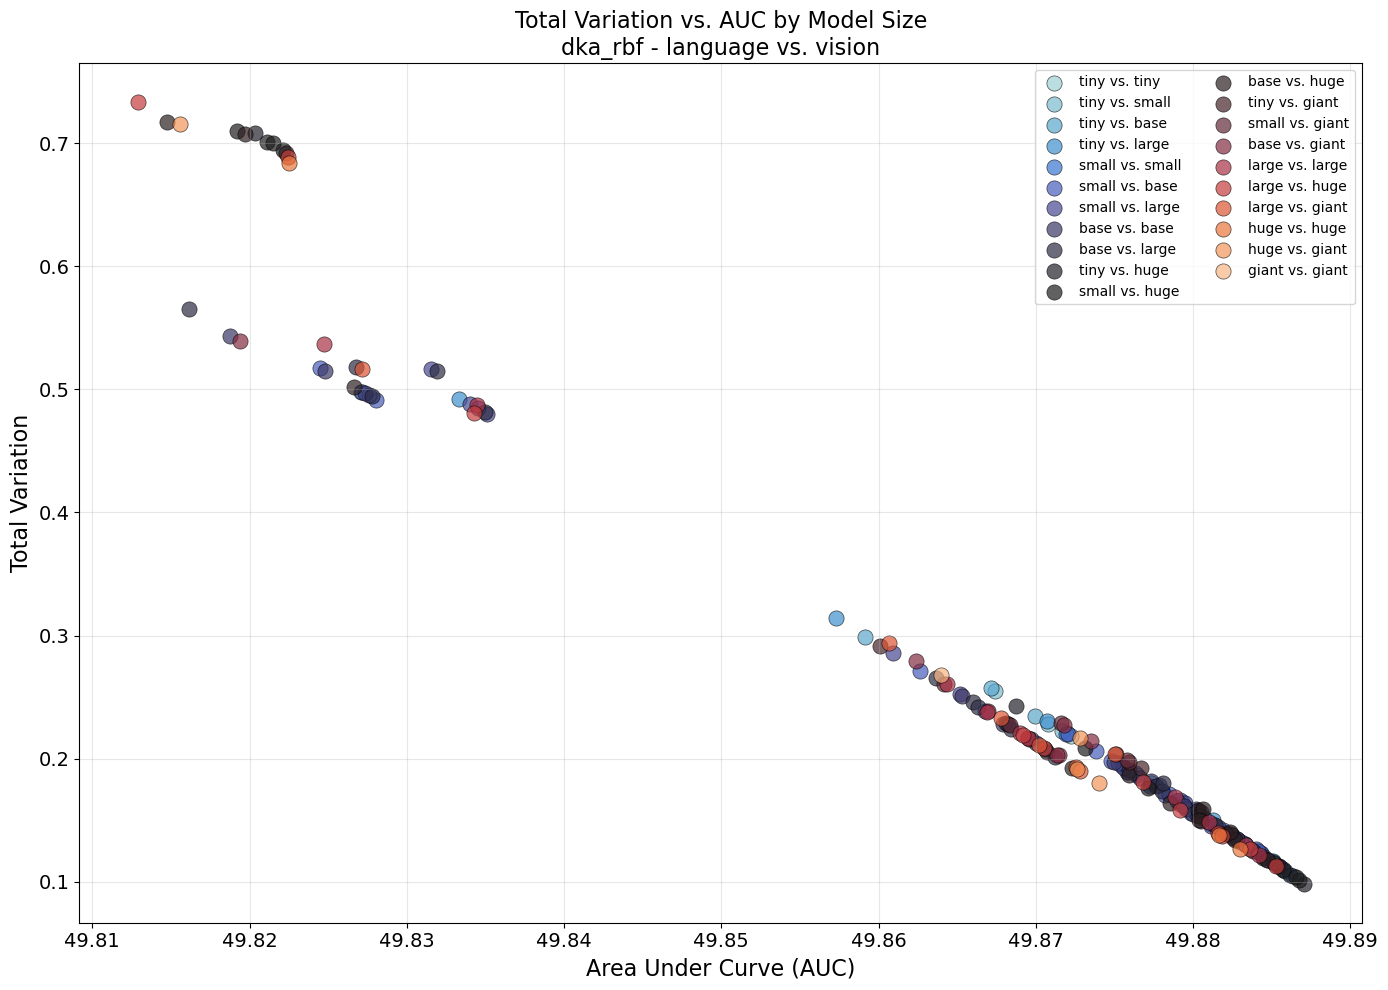


Statistics by Model Size Pair:

base vs. base:
  Count: 15
  Mean AUC: 49.8651 ± 0.0221
  Mean Total Variation: 0.2523 ± 0.1417
  Mean Median Similarity: 0.9999 ± 0.0001

base vs. giant:
  Count: 8
  Mean AUC: 49.8633 ± 0.0181
  Mean Total Variation: 0.2652 ± 0.1136
  Mean Median Similarity: 0.9999 ± 0.0001

base vs. huge:
  Count: 14
  Mean AUC: 49.8623 ± 0.0276
  Mean Total Variation: 0.3013 ± 0.2382
  Mean Median Similarity: 0.9999 ± 0.0001

base vs. large:
  Count: 25
  Mean AUC: 49.8658 ± 0.0206
  Mean Total Variation: 0.2514 ± 0.1404
  Mean Median Similarity: 0.9999 ± 0.0001

giant vs. giant:
  Count: 1
  Mean AUC: 49.8640 ± nan
  Mean Total Variation: 0.2679 ± nan
  Mean Median Similarity: 0.9999 ± nan

huge vs. giant:
  Count: 4
  Mean AUC: 49.8588 ± 0.0288
  Mean Total Variation: 0.3262 ± 0.2603
  Mean Median Similarity: 0.9998 ± 0.0001

huge vs. huge:
  Count: 3
  Mean AUC: 49.8624 ± 0.0346
  Mean Total Variation: 0.3162 ± 0.3183
  Mean Median Similarity: 0.9999 ± 0.0001

la

In [158]:
# Plot Total Variation vs AUC colored by size families

# Get unique size pairs
size_pair_labels = aggregates_df['size_pair']
unique_size_pairs = size_pair_labels.unique()

# Use a color palette for size categories
size_colors = sns.color_palette('icefire', n_colors=len(unique_size_pairs))
size_color_map = {pair: size_colors[i] for i, pair in enumerate(unique_size_pairs)}

# Create the plot
plt.figure(figsize=(14, 10))
for size_pair in unique_size_pairs:
    mask = size_pair_labels == size_pair
    subset = aggregates_df[mask]
    plt.scatter(subset['auc'], subset['total_variation'], 
               label=size_pair, alpha=0.7, s=120, color=size_color_map[size_pair],
               edgecolors='black', linewidth=0.5)

plt.xlabel('Area Under Curve (AUC)', fontsize=fontsize)
plt.ylabel('Total Variation', fontsize=fontsize)
plt.title(f'Total Variation vs. AUC by Model Size\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-6, loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_tv_vs_auc_by_size.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Print statistics by size
print("\n" + "="*80)
print("Statistics by Model Size Pair:")
print("="*80)
for size_pair in sorted(unique_size_pairs):
    subset = aggregates_df[aggregates_df['size_pair'] == size_pair]
    if len(subset) > 0:
        print(f"\n{size_pair}:")
        print(f"  Count: {len(subset)}")
        print(f"  Mean AUC: {subset['auc'].mean():.4f} ± {subset['auc'].std():.4f}")
        print(f"  Mean Total Variation: {subset['total_variation'].mean():.4f} ± {subset['total_variation'].std():.4f}")
        print(f"  Mean Median Similarity: {subset['median_similarity'].mean():.4f} ± {subset['median_similarity'].std():.4f}")

## PCA Analysis: Embedding Model Pairs by Similarity Signal Correlation
Compute correlation between similarity signals across model pairs and use PCA to embed into 2D space, colored by model families

In [159]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_model_family(model_name, modality):
    """
    Determine the family of a model based on its name.
    """
    if modality == 'vision':
        for family in vision_model_families:
            if family in model_name:
                return family
    else:  # language
        for family in language_model_families:
            if family in model_name:
                return family
    return 'unknown'

def extract_similarity_signals(data, model_names_x, model_names_y):
    """
    Extract all pairwise similarity signals from the data.
    Returns a matrix where each row is a model pair's similarity signal across globality values.
    """
    n_models_x = len(model_names_x)
    n_models_y = len(model_names_y)
    sweep_len = data['scores'].shape[2]
    
    signals = []
    pair_labels = []
    pair_info = []
    
    for i in range(n_models_x):
        for j in range(n_models_y):
            # Skip self-comparisons for same modality
            if sim_params['modality_x'] == sim_params['modality_y'] and i == j:
                continue
            
            # Skip duplicate pairs (only keep upper triangle for symmetric cases)
            if sim_params['modality_x'] == sim_params['modality_y'] and i > j:
                continue
            
            model_x = model_names_x[i]
            model_y = model_names_y[j]
            signal = data['scores'][i, j, :]
            
            family_x = get_model_family(model_x, sim_params['modality_x'])
            family_y = get_model_family(model_y, sim_params['modality_y'])
            
            # Create family pair label (canonical ordering)
            if sim_params['modality_x'] == sim_params['modality_y']:
                # Same modality: order alphabetically
                if family_x <= family_y:
                    family_pair = f"{family_x} vs. {family_y}"
                else:
                    family_pair = f"{family_y} vs. {family_x}"
            else:
                # Different modalities: use x vs. y
                family_pair = f"{family_x} vs. {family_y}"
            
            signals.append(signal)
            pair_labels.append(f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}")
            pair_info.append({
                'model_x': model_x,
                'model_y': model_y,
                'model_x_display': model_names_map.get(model_x, model_x),
                'model_y_display': model_names_map.get(model_y, model_y),
                'family_x': family_x,
                'family_y': family_y,
                'family_pair': family_pair
            })
    
    return np.array(signals), pair_labels, pair_info

# Extract similarity signals
signals, pair_labels, pair_info = extract_similarity_signals(data, model_names_x, model_names_y)
print(f"Extracted {len(signals)} model pair signals, each with {signals.shape[1]} globality values")

Extracted 204 model pair signals, each with 40 globality values


In [160]:
from sklearn.decomposition import KernelPCA
# Standardize the signals (z-score normalization)
scaler = StandardScaler()
signals_scaled = scaler.fit_transform(signals)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
# kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.05)
signals_pca = pca.fit_transform(signals_scaled)
# signals_pca = kpca.fit_transform(signals)
# signals_pca = pca.fit_transform(signals)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': signals_pca[:, 0],
    'PC2': signals_pca[:, 1],
    'pair_label': pair_labels,
    'family_pair': [info['family_pair'] for info in pair_info],
    'family_x': [info['family_x'] for info in pair_info],
    'family_y': [info['family_y'] for info in pair_info],
    'model_x': [info['model_x_display'] for info in pair_info],
    'model_y': [info['model_y_display'] for info in pair_info]
})

pca_df.head(10)

PCA explained variance ratio: [0.8717183  0.10942881]
Total variance explained: 0.9811


,PC1,PC2,pair_label,family_pair,family_x,family_y,model_x,model_y
0,1.751261,1.085813,BLOOMZ-560M vs. AugReg-tiny,bloomz vs. augreg,bloomz,augreg,BLOOMZ-560M,AugReg-tiny
1,3.669856,1.686941,BLOOMZ-560M vs. AugReg-small,bloomz vs. augreg,bloomz,augreg,BLOOMZ-560M,AugReg-small
2,4.500789,1.530773,BLOOMZ-560M vs. AugReg-base,bloomz vs. augreg,bloomz,augreg,BLOOMZ-560M,AugReg-base
3,4.744488,1.663789,BLOOMZ-560M vs. AugReg-large,bloomz vs. augreg,bloomz,augreg,BLOOMZ-560M,AugReg-large
4,-13.597375,0.009618,BLOOMZ-560M vs. MAE-base,bloomz vs. mae,bloomz,mae,BLOOMZ-560M,MAE-base
5,-9.057986,-0.711977,BLOOMZ-560M vs. MAE-large,bloomz vs. mae,bloomz,mae,BLOOMZ-560M,MAE-large
6,-10.388227,0.442051,BLOOMZ-560M vs. MAE-huge,bloomz vs. mae,bloomz,mae,BLOOMZ-560M,MAE-huge
7,3.133919,-1.304527,BLOOMZ-560M vs. DINOv2-small,bloomz vs. dinov2,bloomz,dinov2,BLOOMZ-560M,DINOv2-small
8,3.888588,-2.319651,BLOOMZ-560M vs. DINOv2-base,bloomz vs. dinov2,bloomz,dinov2,BLOOMZ-560M,DINOv2-base
9,4.138245,-2.734863,BLOOMZ-560M vs. DINOv2-large,bloomz vs. dinov2,bloomz,dinov2,BLOOMZ-560M,DINOv2-large


Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\pca_similarity_signals_by_family.png


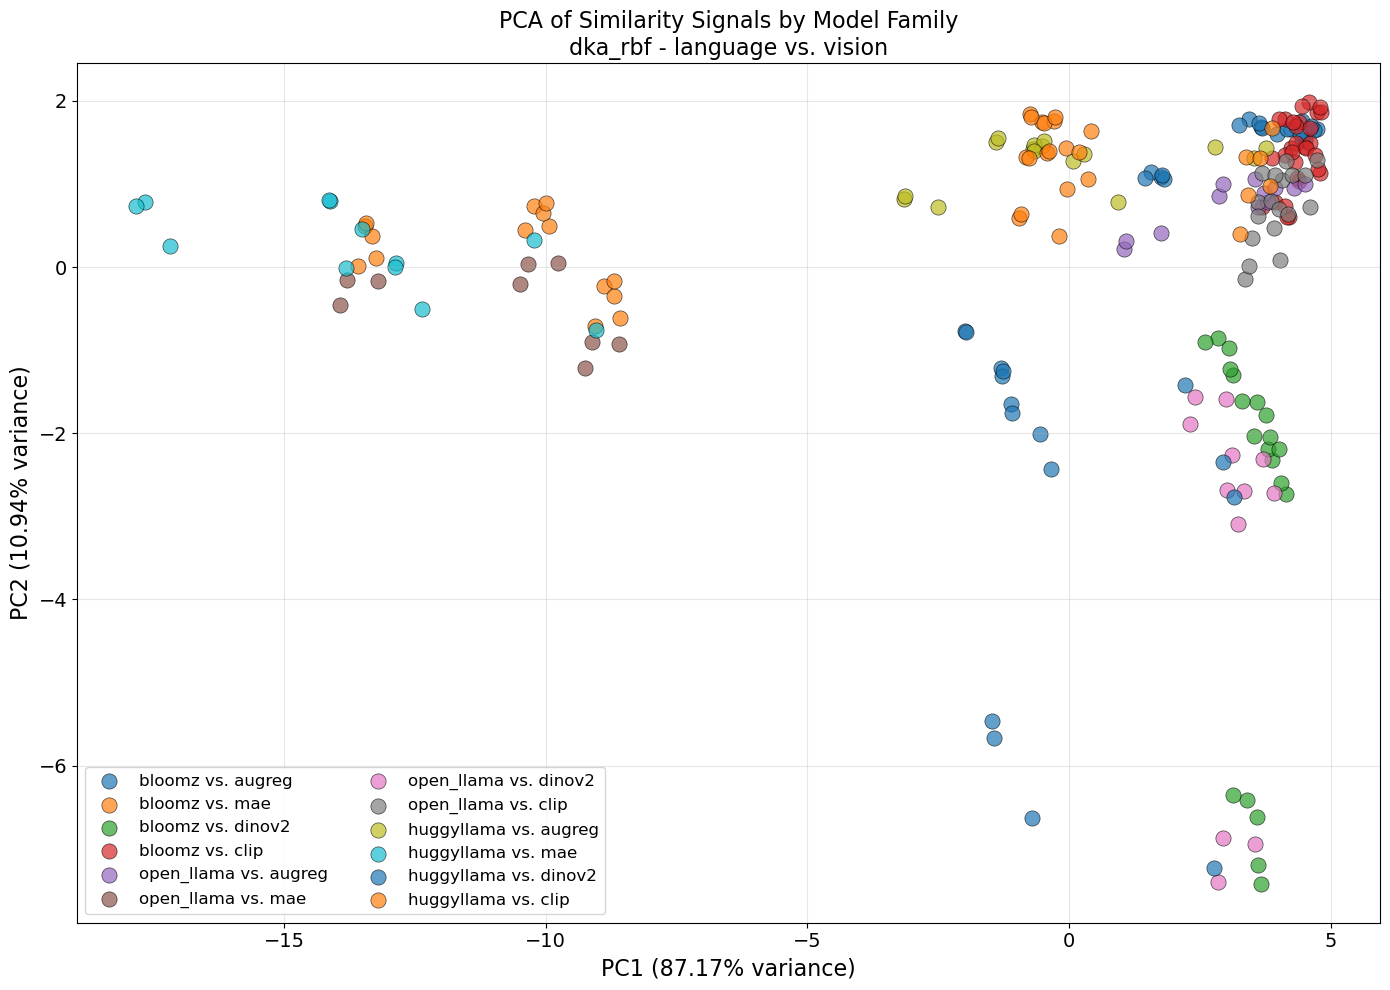


PCA Embedding Statistics by Family Pair:

bloomz vs. augreg:
  Count: 20
  PC1 mean: 3.5147 ± 1.1701
  PC2 mean: 1.5217 ± 0.2608

bloomz vs. clip:
  Count: 30
  PC1 mean: 4.3696 ± 0.2905
  PC2 mean: 1.3946 ± 0.4168

bloomz vs. dinov2:
  Count: 20
  PC1 mean: 3.5036 ± 0.4229
  PC2 mean: -3.0185 ± 2.3091

bloomz vs. mae:
  Count: 15
  PC1 mean: -10.7711 ± 2.0187
  PC2 mean: 0.1686 ± 0.4869

huggyllama vs. augreg:
  Count: 16
  PC1 mean: -0.1957 ± 2.1043
  PC2 mean: 1.2702 ± 0.2925

huggyllama vs. clip:
  Count: 24
  PC1 mean: 0.6176 ± 1.7837
  PC2 mean: 1.2792 ± 0.4560

huggyllama vs. dinov2:
  Count: 16
  PC1 mean: -0.2158 ± 1.8399
  PC2 mean: -2.7939 ± 2.1639

huggyllama vs. mae:
  Count: 12
  PC1 mean: -13.8026 ± 2.7334
  PC2 mean: 0.2452 ± 0.5159

open_llama vs. augreg:
  Count: 12
  PC1 mean: 3.0937 ± 1.1910
  PC2 mean: 0.7626 ± 0.2892

open_llama vs. clip:
  Count: 18
  PC1 mean: 3.9691 ± 0.3970
  PC2 mean: 0.7277 ± 0.4363

open_llama vs. dinov2:
  Count: 12
  PC1 mean: 3.1185 ± 0

In [161]:
# Create PCA scatter plot colored by family pairs

unique_family_pairs = pca_df['family_pair'].unique()
n_families = len(unique_family_pairs)

# Use a distinct color palette
family_colors = sns.color_palette('tab10', n_colors=n_families)
family_color_map = {family: family_colors[i] for i, family in enumerate(unique_family_pairs)}

plt.figure(figsize=(14, 10))

for family_pair in unique_family_pairs:
    mask = pca_df['family_pair'] == family_pair
    subset = pca_df[mask]
    plt.scatter(subset['PC1'], subset['PC2'], 
               label=family_pair, alpha=0.7, s=120, 
               color=family_color_map[family_pair],
               edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=fontsize)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=fontsize)
plt.title(f'PCA of Similarity Signals by Model Family\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'pca_similarity_signals_by_family.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("PCA Embedding Statistics by Family Pair:")
print("="*80)
for family_pair in sorted(unique_family_pairs):
    subset = pca_df[pca_df['family_pair'] == family_pair]
    if len(subset) > 0:
        print(f"\n{family_pair}:")
        print(f"  Count: {len(subset)}")
        print(f"  PC1 mean: {subset['PC1'].mean():.4f} ± {subset['PC1'].std():.4f}")
        print(f"  PC2 mean: {subset['PC2'].mean():.4f} ± {subset['PC2'].std():.4f}")

Saved figure to: post_processing\figures\val_wit_1024\dka_rbf_layer_final\language_vs_vision\pca_similarity_signals_by_primary_family.png


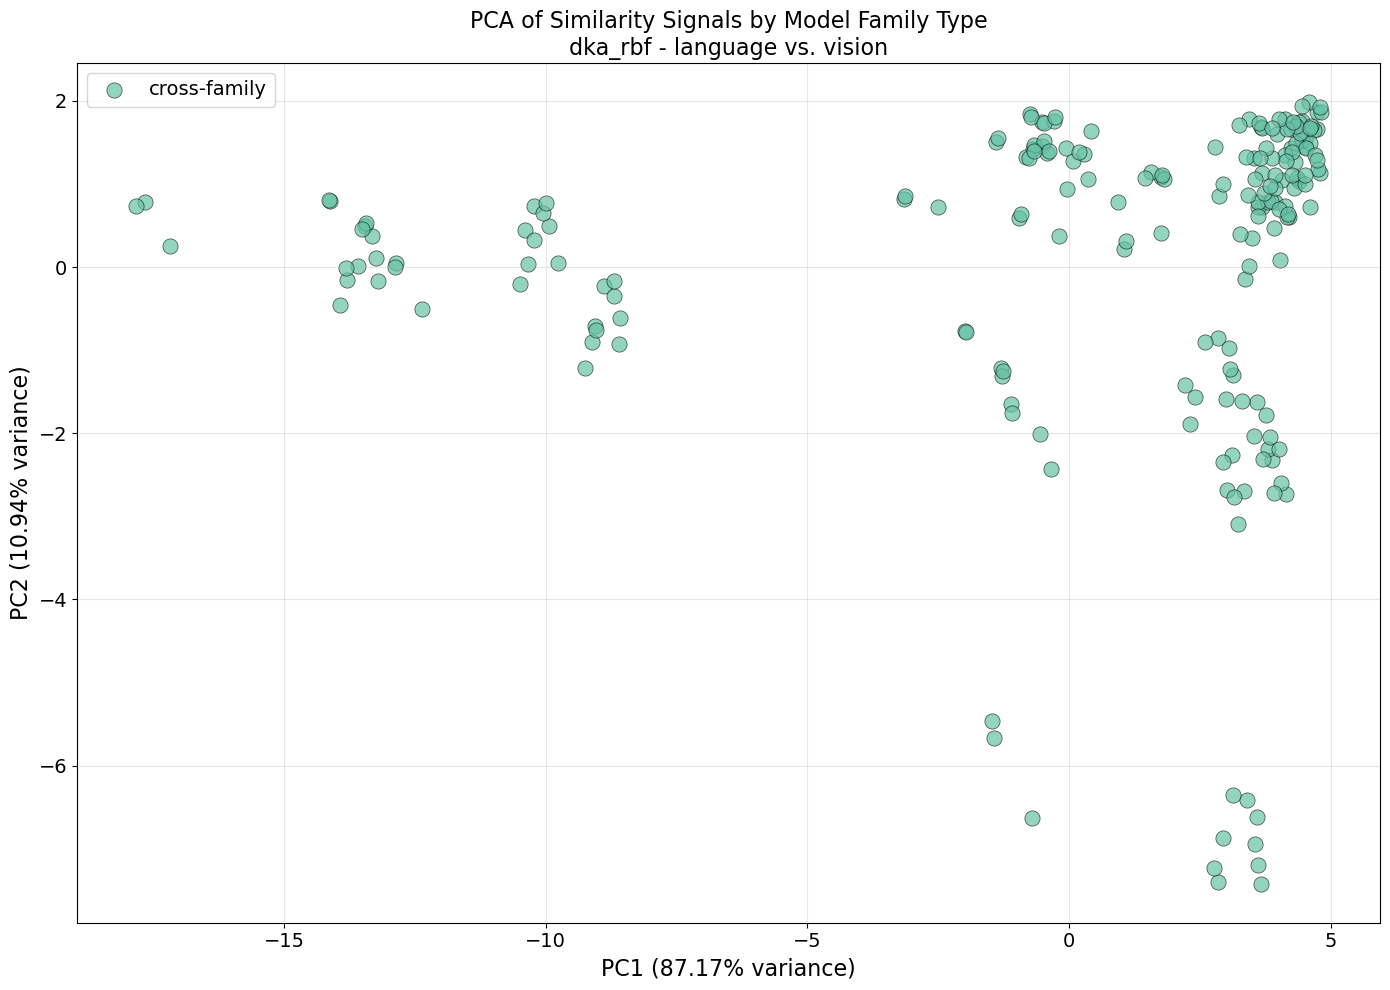

In [162]:
# Alternative: Create separate scatter plot for each family's models
# This shows individual model families rather than family pairs

# Extract individual family labels
pca_df['primary_family'] = pca_df.apply(
    lambda row: row['family_x'] if row['family_x'] == row['family_y'] else 'cross-family',
    axis=1
)

unique_primary_families = pca_df['primary_family'].unique()
n_primary = len(unique_primary_families)

# Use a distinct color palette
primary_colors = sns.color_palette('Set2', n_colors=n_primary)
primary_color_map = {family: primary_colors[i] for i, family in enumerate(unique_primary_families)}

plt.figure(figsize=(14, 10))

for primary_family in unique_primary_families:
    mask = pca_df['primary_family'] == primary_family
    subset = pca_df[mask]
    plt.scatter(subset['PC1'], subset['PC2'], 
               label=primary_family, alpha=0.7, s=120, 
               color=primary_color_map[primary_family],
               edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=fontsize)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=fontsize)
plt.title(f'PCA of Similarity Signals by Model Family Type\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-2, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'pca_similarity_signals_by_primary_family.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()